# Apartado 3. Comparación de las medias trimestrales de la irradiación, la temperatura y la precipitación en la celda 01.


**NOTA:** Para cada variable se calculan intervalos de confianza Bootstrap para la media en cada trimestre. Después se comparan los solapes entre trimestres para dos niveles de confianza: 50% y 99%.

## Importación y carga de datos

En esta sección se importan los datos y librerías necesarias para el análisis del apartado 3.

In [1]:
from carga_de_datos import *
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 3.1. Calcular los intervalos de confianza para la media de los datos de irradiación de la celda 01 por trimestres mediante Bootstrap, con un nivel de confianza del 50% y del 99%. ¿Para qué pares de trimestres se solapan sus respectivos intervalos de confianza? ¿La respuesta a la pregunta anterior depende del nivel de confianza?

In [2]:
print('En primer lugar definimos los parámetros comunes de Bootstrap que reutilizaremos en todo el apartado.')
R = 9999
estadistico = np.mean
niveles_confianza = [0.50, 0.99]

En primer lugar definimos los parámetros comunes de Bootstrap que reutilizaremos en todo el apartado.


In [3]:
print('En segundo lugar preparamos los datos de irradiación por trimestres en la celda 01.')
df_irrad = df_orig_irrad.copy()
df_irrad['FECHA'] = pd.to_datetime(df_irrad['FECHA'])
df_irrad['TRIMESTRE'] = df_irrad['FECHA'].dt.quarter

En segundo lugar preparamos los datos de irradiación por trimestres en la celda 01.


En tercer lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de irradiación.

Tabla de intervalos bootstrap para irradiación:
  Trimestre         Media                                    IC 50%  \
0        T1  5.265756e+05   (522077.39115084906, 530817.9930921276)   
1        T2  1.025743e+06  (1020845.8313355838, 1030302.5527043877)   
2        T3  1.030350e+06  (1026135.4577978313, 1034145.5482538269)   
3        T4  4.384121e+05    (434991.8935770466, 441963.4905692356)   

                                     IC 99%  
0    (510155.8595934368, 542941.7166840835)  
1  (1006780.3454405599, 1043105.2449932871)  
2   (1014412.486846003, 1045189.3060764387)  
3   (425046.4819419641, 452213.59013863734)  

En cuarto lugar representamos gráficamente los intervalos de confianza Bootstrap de la irradiación por trimestres.


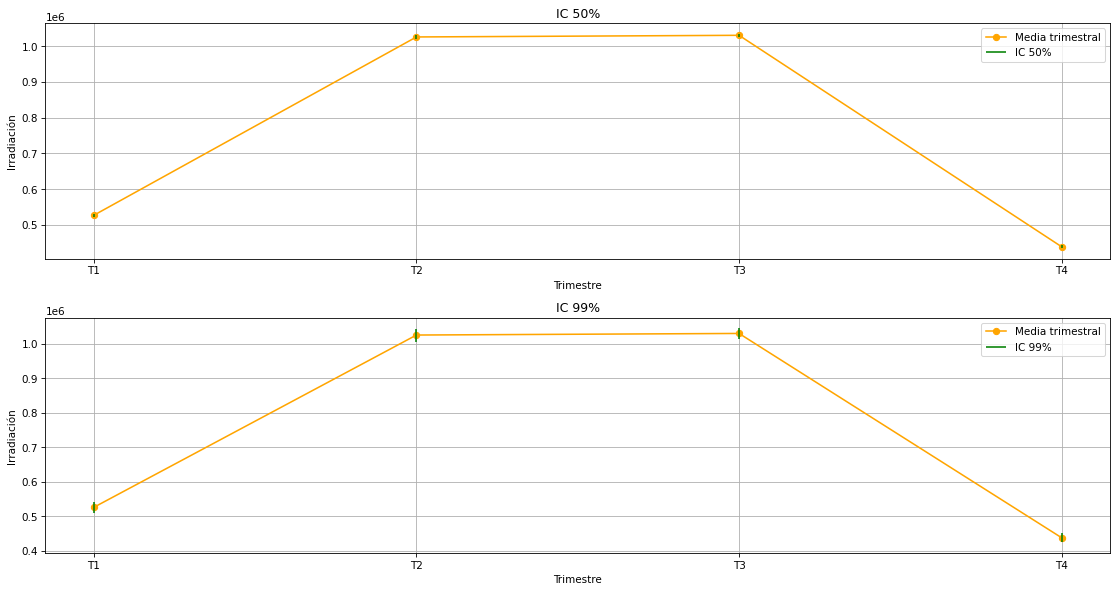

In [4]:
print('En tercer lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de irradiación.')
resultados_irrad = []
for trimestre in sorted(df_irrad['TRIMESTRE'].unique()):
    x = df_irrad.loc[df_irrad['TRIMESTRE'] == trimestre, 'IRRAD_CELDA01'].to_numpy(dtype=float)
    fila = {'Trimestre': f'T{trimestre}', 'Media': np.mean(x)}

    for nivel_confianza in niveles_confianza:
        muestra_orig = (x,)
        res_BCa = stats.bootstrap(
            muestra_orig,
            estadistico,
            confidence_level=nivel_confianza,
            n_resamples=R,
            method='BCA',
            random_state=999,
        )
        lim_inf_BCa, lim_sup_BCa = res_BCa.confidence_interval
        fila[f'IC {int(100 * nivel_confianza)}%'] = (lim_inf_BCa, lim_sup_BCa)

    resultados_irrad.append(fila)

tabla_irrad = pd.DataFrame(resultados_irrad)
print('\nTabla de intervalos bootstrap para irradiación:')
print(tabla_irrad[['Trimestre', 'Media', 'IC 50%', 'IC 99%']])

print('\nEn cuarto lugar representamos gráficamente los intervalos de confianza Bootstrap de la irradiación por trimestres.')
trimestres = tabla_irrad['Trimestre'].tolist()
x_pos = np.arange(1, len(trimestres) + 1)
medias = tabla_irrad['Media'].to_numpy(dtype=float)

fig = plt.figure(1, figsize=(15, 8))
for idx, etiqueta in enumerate(['IC 50%', 'IC 99%'], start=1):
    lim_inf = tabla_irrad[etiqueta].apply(lambda z: z[0]).to_numpy(dtype=float)
    lim_sup = tabla_irrad[etiqueta].apply(lambda z: z[1]).to_numpy(dtype=float)
    plt.subplot(2, 1, idx)
    plt.plot(x_pos, medias, 'o-', color='orange', label='Media trimestral')
    plt.vlines(x_pos, lim_inf, lim_sup, color='green', label=etiqueta)
    plt.xlabel('Trimestre')
    plt.ylabel('Irradiación')
    plt.xticks(x_pos, trimestres)
    plt.title(etiqueta)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.1： Intervalos de confianza Bootstrap de la irradiación por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
print('En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.')
for nivel_confianza in niveles_confianza:
    pares_solape = []
    etiqueta = f'IC {int(100 * nivel_confianza)}%'

    for i in range(len(tabla_irrad)):
        for j in range(i + 1, len(tabla_irrad)):
            a1, b1 = tabla_irrad.loc[i, etiqueta]
            a2, b2 = tabla_irrad.loc[j, etiqueta]
            if not (b1 < a2 or b2 < a1):
                pares_solape.append(f"{tabla_irrad.loc[i, 'Trimestre']}-{tabla_irrad.loc[j, 'Trimestre']}")

    if len(pares_solape) > 0:
        print(f"\nPares con solape para {etiqueta}: {', '.join(pares_solape)}")
    else:
        print(f"\nNo hay pares con solape para {etiqueta}.")

En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.

Pares con solape para IC 50%: T2-T3

Pares con solape para IC 99%: T2-T3


In [6]:
print('En primer lugar preparamos los datos de temperatura por trimestres en la celda 01.')
df_temp = df_orig_temp.copy()
df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'])
df_temp['TRIMESTRE'] = df_temp['FECHA'].dt.quarter

En primer lugar preparamos los datos de temperatura por trimestres en la celda 01.


En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de temperatura.

Tabla de intervalos bootstrap para temperatura:
  Trimestre      Media                                    IC 50%  \
0        T1  10.698915  (10.629985292286133, 10.763913836599997)   
1        T2  21.230702   (21.12147852529385, 21.345113871170906)   
2        T3  28.164456  (28.087024845698586, 28.239550889988152)   
3        T4  14.274837  (14.172110120681612, 14.380438950018856)   

                                     IC 99%  
0  (10.443273066154118, 10.952037517708261)  
1  (20.807805388812824, 21.651667994509314)  
2     (27.8655270576413, 28.45557196860245)  
3  (13.874505491626579, 14.693414048772558)  

En tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la temperatura por trimestres.


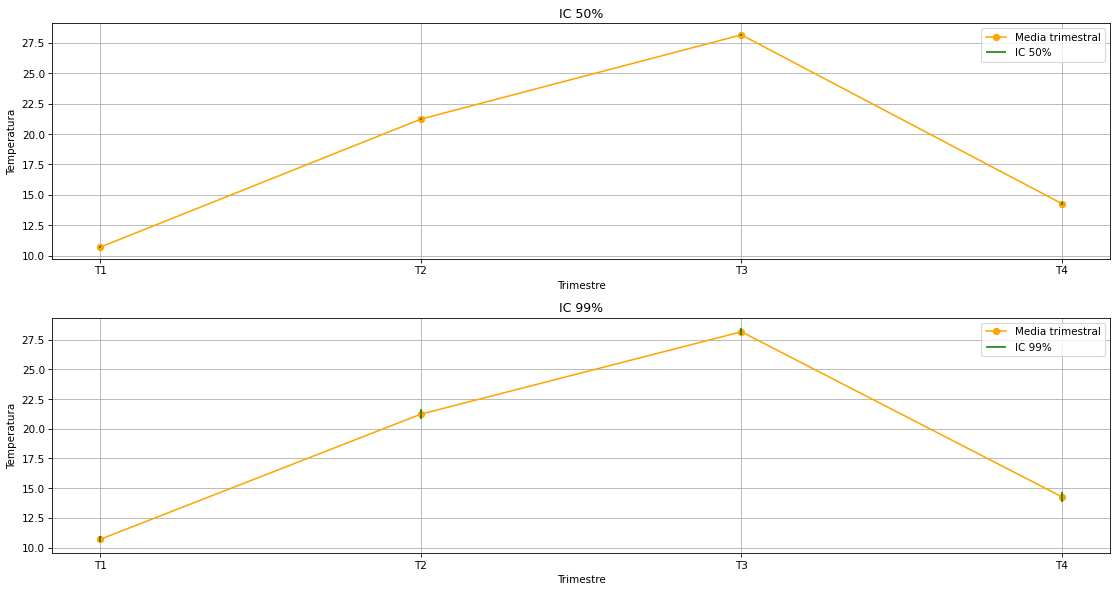

In [7]:
print('En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de temperatura.')
resultados_temp = []
for trimestre in sorted(df_temp['TRIMESTRE'].unique()):
    x = df_temp.loc[df_temp['TRIMESTRE'] == trimestre, 'TEMP_CELDA01'].to_numpy(dtype=float)
    fila = {'Trimestre': f'T{trimestre}', 'Media': np.mean(x)}

    for nivel_confianza in niveles_confianza:
        muestra_orig = (x,)
        res_BCa = stats.bootstrap(
            muestra_orig,
            estadistico,
            confidence_level=nivel_confianza,
            n_resamples=R,
            method='BCA',
            random_state=999,
        )
        lim_inf_BCa, lim_sup_BCa = res_BCa.confidence_interval
        fila[f'IC {int(100 * nivel_confianza)}%'] = (lim_inf_BCa, lim_sup_BCa)

    resultados_temp.append(fila)

tabla_temp = pd.DataFrame(resultados_temp)
print('\nTabla de intervalos bootstrap para temperatura:')
print(tabla_temp[['Trimestre', 'Media', 'IC 50%', 'IC 99%']])

print('\nEn tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la temperatura por trimestres.')
trimestres = tabla_temp['Trimestre'].tolist()
x_pos = np.arange(1, len(trimestres) + 1)
medias = tabla_temp['Media'].to_numpy(dtype=float)

fig = plt.figure(1, figsize=(15, 8))
for idx, etiqueta in enumerate(['IC 50%', 'IC 99%'], start=1):
    lim_inf = tabla_temp[etiqueta].apply(lambda z: z[0]).to_numpy(dtype=float)
    lim_sup = tabla_temp[etiqueta].apply(lambda z: z[1]).to_numpy(dtype=float)
    plt.subplot(2, 1, idx)
    plt.plot(x_pos, medias, 'o-', color='orange', label='Media trimestral')
    plt.vlines(x_pos, lim_inf, lim_sup, color='green', label=etiqueta)
    plt.xlabel('Trimestre')
    plt.ylabel('Temperatura')
    plt.xticks(x_pos, trimestres)
    plt.title(etiqueta)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.2： Intervalos de confianza Bootstrap de la temperatura por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print('En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.')
for nivel_confianza in niveles_confianza:
    pares_solape = []
    etiqueta = f'IC {int(100 * nivel_confianza)}%'

    for i in range(len(tabla_temp)):
        for j in range(i + 1, len(tabla_temp)):
            a1, b1 = tabla_temp.loc[i, etiqueta]
            a2, b2 = tabla_temp.loc[j, etiqueta]
            if not (b1 < a2 or b2 < a1):
                pares_solape.append(f"{tabla_temp.loc[i, 'Trimestre']}-{tabla_temp.loc[j, 'Trimestre']}")

    if len(pares_solape) > 0:
        print(f"\nPares con solape para {etiqueta}: {', '.join(pares_solape)}")
    else:
        print(f"\nNo hay pares con solape para {etiqueta}.")

En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.

No hay pares con solape para IC 50%.

No hay pares con solape para IC 99%.


In [9]:
print('En primer lugar preparamos los datos de precipitación por trimestres en la celda 01.')
df_precip = df_orig_precip.copy()
df_precip['FECHA'] = pd.to_datetime(df_precip['FECHA'])
df_precip['TRIMESTRE'] = df_precip['FECHA'].dt.quarter

En primer lugar preparamos los datos de precipitación por trimestres en la celda 01.


En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de precipitación.

Tabla de intervalos bootstrap para precipitación:
  Trimestre     Media                                            IC 50%  \
0        T1  0.000072    (6.904478764697276e-05, 7.577030615523581e-05)   
1        T2  0.000036  (3.3429246331678465e-05, 3.7743825346284156e-05)   
2        T3  0.000013  (1.1374683662219165e-05, 1.4194747972457946e-05)   
3        T4  0.000066    (6.225355879409958e-05, 6.920254095616218e-05)   

                                            IC 99%  
0    (6.07740539940873e-05, 8.632499273383459e-05)  
1  (2.8372724069517823e-05, 4.490330792165593e-05)  
2   (8.64777939303942e-06, 2.0378595259640828e-05)  
3   (5.380854159299079e-05, 8.000567290795358e-05)  

En tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la precipitación por trimestres.


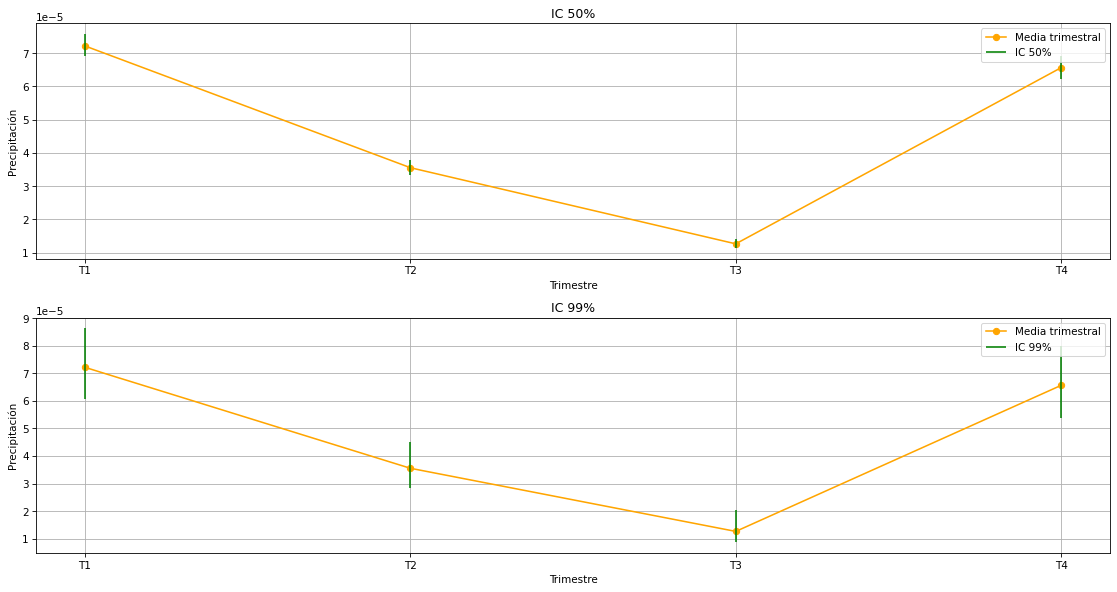

In [10]:
print('En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de precipitación.')
resultados_precip = []
for trimestre in sorted(df_precip['TRIMESTRE'].unique()):
    x = df_precip.loc[df_precip['TRIMESTRE'] == trimestre, 'PRECIP_CELDA01'].to_numpy(dtype=float)
    fila = {'Trimestre': f'T{trimestre}', 'Media': np.mean(x)}

    for nivel_confianza in niveles_confianza:
        muestra_orig = (x,)
        res_BCa = stats.bootstrap(
            muestra_orig,
            estadistico,
            confidence_level=nivel_confianza,
            n_resamples=R,
            method='BCA',
            random_state=999,
        )
        lim_inf_BCa, lim_sup_BCa = res_BCa.confidence_interval
        fila[f'IC {int(100 * nivel_confianza)}%'] = (lim_inf_BCa, lim_sup_BCa)

    resultados_precip.append(fila)

tabla_precip = pd.DataFrame(resultados_precip)
print('\nTabla de intervalos bootstrap para precipitación:')
print(tabla_precip[['Trimestre', 'Media', 'IC 50%', 'IC 99%']])

print('\nEn tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la precipitación por trimestres.')
trimestres = tabla_precip['Trimestre'].tolist()
x_pos = np.arange(1, len(trimestres) + 1)
medias = tabla_precip['Media'].to_numpy(dtype=float)

fig = plt.figure(1, figsize=(15, 8))
for idx, etiqueta in enumerate(['IC 50%', 'IC 99%'], start=1):
    lim_inf = tabla_precip[etiqueta].apply(lambda z: z[0]).to_numpy(dtype=float)
    lim_sup = tabla_precip[etiqueta].apply(lambda z: z[1]).to_numpy(dtype=float)
    plt.subplot(2, 1, idx)
    plt.plot(x_pos, medias, 'o-', color='orange', label='Media trimestral')
    plt.vlines(x_pos, lim_inf, lim_sup, color='green', label=etiqueta)
    plt.xlabel('Trimestre')
    plt.ylabel('Precipitación')
    plt.xticks(x_pos, trimestres)
    plt.title(etiqueta)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.3： Intervalos de confianza Bootstrap de la precipitación por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print('En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.')
for nivel_confianza in niveles_confianza:
    pares_solape = []
    etiqueta = f'IC {int(100 * nivel_confianza)}%'

    for i in range(len(tabla_precip)):
        for j in range(i + 1, len(tabla_precip)):
            a1, b1 = tabla_precip.loc[i, etiqueta]
            a2, b2 = tabla_precip.loc[j, etiqueta]
            if not (b1 < a2 or b2 < a1):
                pares_solape.append(f"{tabla_precip.loc[i, 'Trimestre']}-{tabla_precip.loc[j, 'Trimestre']}")

    if len(pares_solape) > 0:
        print(f"\nPares con solape para {etiqueta}: {', '.join(pares_solape)}")
    else:
        print(f"\nNo hay pares con solape para {etiqueta}.")

En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.

Pares con solape para IC 50%: T1-T4

Pares con solape para IC 99%: T1-T4
